# **Section 1: Data Loading & Decoding**

---



Load, Decode, and Split Data

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import classification_report, precision_recall_fscore_support

# Load and Decode
(x_train_raw, y_train_imdb), (x_test_raw, y_test_imdb) = tf.keras.datasets.imdb.load_data()
word_index = tf.keras.datasets.imdb.get_word_index()
index2word = {i + 3: word for word, i in word_index.items()}
index2word[0], index2word[1], index2word[2] = '[pad]', '[bos]', '[oov]'

x_train_text = np.array([' '.join([index2word.get(idx, '[oov]') for idx in text]) for text in x_train_raw])
x_test_text = np.array([' '.join([index2word.get(idx, '[oov]') for idx in text]) for text in x_test_raw])

# Create Development Set
x_train_full, x_dev_text, y_train_full, y_dev = train_test_split(
    x_train_text, y_train_imdb, test_size=0.2, random_state=42
)

# **Section 2: Part A (Traditional ML & Information Gain)**

---



Custom Vocabulary Selection (Information Gain)

In [3]:
# Hyperparameters (Adjust these based on Development Data performance)
n = 100   # Most frequent
k = 100   # Most rare (document frequency threshold)
m = 1000  # Final vocabulary size (Information Gain)

# Frequency Filtering
cv_freq = CountVectorizer(binary=True, min_df=k)
X_freq = cv_freq.fit_transform(x_train_full)
words = cv_freq.get_feature_names_out()

doc_counts = np.asarray(X_freq.sum(axis=0)).flatten()

# Remove the n most frequent
top_n_indices = np.argsort(doc_counts)[-n:]
mask = np.ones(len(words), dtype=bool)
mask[top_n_indices] = False
filtered_words = words[mask]
X_filtered = X_freq[:, mask]

# Information Gain Selection
# mutual_info_classif calculates Information Gain
ig_scores = mutual_info_classif(X_filtered, y_train_full, discrete_features=True)
top_m_indices = np.argsort(ig_scores)[-m:]
final_vocabulary = filtered_words[top_m_indices]

# Final Vectorization
vectorizer = CountVectorizer(binary=True, vocabulary=final_vocabulary)
X_train = vectorizer.transform(x_train_full).toarray()
X_dev = vectorizer.transform(x_dev_text).toarray()
X_test = vectorizer.transform(x_test_text).toarray()

Learning Curves Implementation

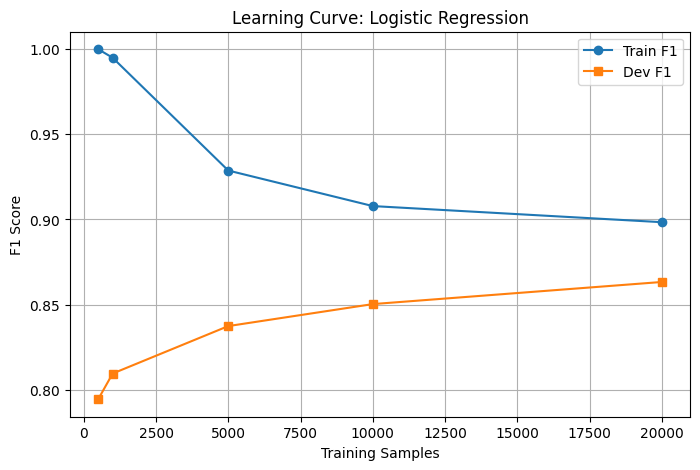

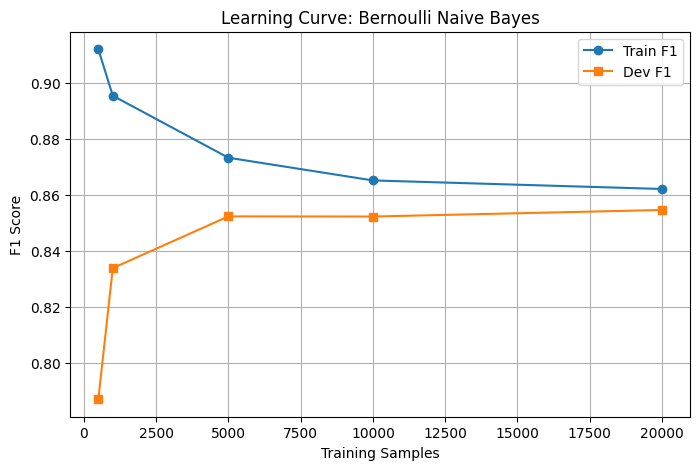

In [4]:
def plot_learning_curves(model, name):
    train_sizes = [500, 1000, 5000, 10000, len(X_train)]
    results = {'train': [], 'dev': []}

    for size in train_sizes:
        model.fit(X_train[:size], y_train_full[:size])

        # Get metrics for Positive class (index 1)
        train_metrics = precision_recall_fscore_support(y_train_full[:size], model.predict(X_train[:size]), average='binary')
        dev_metrics = precision_recall_fscore_support(y_dev, model.predict(X_dev), average='binary')

        results['train'].append(train_metrics[2]) # F1 Score
        results['dev'].append(dev_metrics[2])

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, results['train'], 'o-', label='Train F1')
    plt.plot(train_sizes, results['dev'], 's-', label='Dev F1')
    plt.title(f'Learning Curve: {name}')
    plt.xlabel('Training Samples')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
    plt.show()

# Algorithm implementations
lr_model = LogisticRegression(penalty='l2', max_iter=1000) # L2 Regularization [cite: 11]
nb_model = BernoulliNB() # Bernoulli Naive Bayes [cite: 8]

plot_learning_curves(lr_model, "Logistic Regression")
plot_learning_curves(nb_model, "Bernoulli Naive Bayes")

Final Evaluation (Test Data)

In [5]:
# Final evaluation after training on all available training data
for name, model in [("Logistic Regression", lr_model), ("Naive Bayes", nb_model)]:
    model.fit(X_train, y_train_full)
    y_pred = model.predict(X_test)
    print(f"\n--- {name} Final Test Results ---")
    print(classification_report(y_test_imdb, y_pred, digits=4)) # Shows micro/macro averages


--- Logistic Regression Final Test Results ---
              precision    recall  f1-score   support

           0     0.8705    0.8560    0.8632     12500
           1     0.8584    0.8726    0.8654     12500

    accuracy                         0.8643     25000
   macro avg     0.8644    0.8643    0.8643     25000
weighted avg     0.8644    0.8643    0.8643     25000


--- Naive Bayes Final Test Results ---
              precision    recall  f1-score   support

           0     0.8474    0.8566    0.8520     12500
           1     0.8551    0.8458    0.8504     12500

    accuracy                         0.8512     25000
   macro avg     0.8512    0.8512    0.8512     25000
weighted avg     0.8512    0.8512    0.8512     25000



# **Section 3: Part B (Stacked Bidirectional RNN & GloVe)**

---



Model Architecture (Stacked Bidirectional RNN)

Hardware Check: Training on cuda
Loading IMDB dataset...
Processing Embeddings...

Starting Training on GPU...
Epoch 1/10 | Train Loss: 0.5519 | Dev Loss: 0.4294
Epoch 2/10 | Train Loss: 0.4037 | Dev Loss: 0.4026
Epoch 3/10 | Train Loss: 0.3715 | Dev Loss: 0.3901
Epoch 4/10 | Train Loss: 0.3501 | Dev Loss: 0.4111
Early Stopping counter: 1 out of 2
Epoch 5/10 | Train Loss: 0.3415 | Dev Loss: 0.3536
Epoch 6/10 | Train Loss: 0.3231 | Dev Loss: 0.3500
Epoch 7/10 | Train Loss: 0.3105 | Dev Loss: 0.3452
Epoch 8/10 | Train Loss: 0.2978 | Dev Loss: 0.3480
Early Stopping counter: 1 out of 2
Epoch 9/10 | Train Loss: 0.2915 | Dev Loss: 0.3369
Epoch 10/10 | Train Loss: 0.2687 | Dev Loss: 0.3426
Early Stopping counter: 1 out of 2


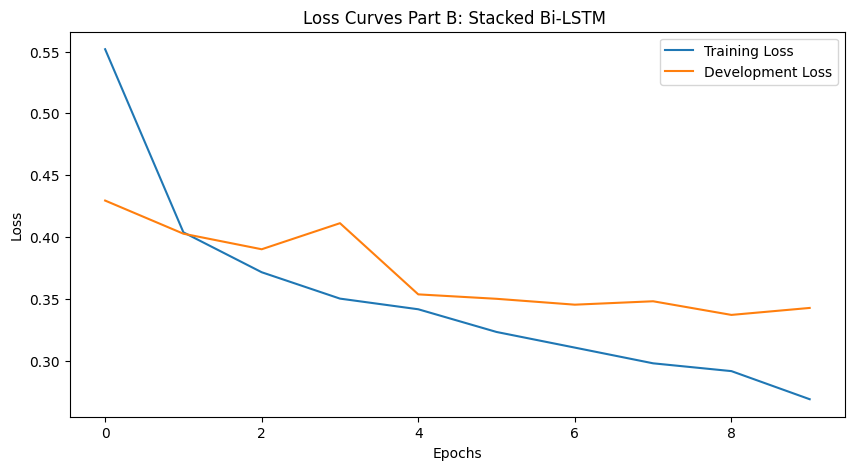


--- Final Test Results (Part B) ---
              precision    recall  f1-score   support

         0.0     0.8790    0.8370    0.8575     12500
         1.0     0.8444    0.8848    0.8641     12500

    accuracy                         0.8609     25000
   macro avg     0.8617    0.8609    0.8608     25000
weighted avg     0.8617    0.8609    0.8608     25000



In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import requests
import zipfile
import os
import io
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# GPU SETUP & HYPERPARAMETERS
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Hardware Check: Training on {device}")

MAX_LEN = 200        # Max sequence length
VOCAB_SIZE = 10000   # Size of vocabulary
EMBED_DIM = 100      # Dimension of GloVe vectors
HIDDEN_DIM = 128     # Hidden units in LSTM
NUM_LAYERS = 2       # Stacked layers
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001

# DATA LOADING (IMDB)
print("Loading IMDB dataset...")
(x_train_seq, y_train_full), (x_test_seq, y_test) = tf.keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

word_index = tf.keras.datasets.imdb.get_word_index()
index2word = {i + 3: word for word, i in word_index.items()}
index2word[0] = '<pad>'
index2word[1] = '<bos>'
index2word[2] = '<unk>'

def decode_reviews(sequences):
    return [' '.join([index2word.get(idx, '<unk>') for idx in seq]) for seq in sequences]

x_train_text = decode_reviews(x_train_seq)
x_test_text = decode_reviews(x_test_seq)

# Create Development Set
x_train_split, x_dev_split, y_train_split, y_dev_split = train_test_split(
    x_train_text, y_train_full, test_size=0.2, random_state=42
)

# GLOVE EMBEDDINGS (Manual Download)
glove_file = 'glove.6B.100d.txt'
if not os.path.exists(glove_file):
    print(" Downloading GloVe embeddings (approx 1 min)...")
    url = "http://nlp.stanford.edu/data/glove.6B.zip"
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall()
    print(" GloVe Downloaded.")

print("Processing Embeddings...")
embeddings_index = {}
with open(glove_file, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

# Build Custom Vocabulary & Weight Matrix
all_words = [word for text in x_train_split for word in text.split()]
from collections import Counter
word_counts = Counter(all_words)
common_words = word_counts.most_common(VOCAB_SIZE - 2)

my_word_to_idx = {"<pad>": 0, "<unk>": 1}
for word, _ in common_words:
    my_word_to_idx[word] = len(my_word_to_idx)

# Initialize Embedding Matrix
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
for word, i in my_word_to_idx.items():
    if i < VOCAB_SIZE:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
        else:
            embedding_matrix[i] = np.random.normal(scale=0.6, size=(EMBED_DIM,))

weights_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)

# TENSOR PREPARATION
def vectorize_text(texts, word_map, max_len):
    tensor_data = []
    for text in texts:
        tokens = text.split()
        seq = [word_map.get(t, 1) for t in tokens[:max_len]]
        if len(seq) < max_len:
            seq += [0] * (max_len - len(seq))
        tensor_data.append(seq)
    return torch.tensor(tensor_data, dtype=torch.long)

X_train_t = vectorize_text(x_train_split, my_word_to_idx, MAX_LEN)
y_train_t = torch.tensor(y_train_split, dtype=torch.float32).unsqueeze(1)
X_dev_t = vectorize_text(x_dev_split, my_word_to_idx, MAX_LEN)
y_dev_t = torch.tensor(y_dev_split, dtype=torch.float32).unsqueeze(1)
X_test_t = vectorize_text(x_test_text, my_word_to_idx, MAX_LEN)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
dev_loader = DataLoader(TensorDataset(X_dev_t, y_dev_t), batch_size=BATCH_SIZE, pin_memory=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, pin_memory=True)

# MODEL ARCHITECTURE
class StackedBiLSTM(nn.Module):
    def __init__(self, weights, hidden_dim, num_layers):
        super(StackedBiLSTM, self).__init__()

        # Freeze Embeddings by setting freeze=True
        self.embedding = nn.Embedding.from_pretrained(weights, freeze=True, padding_idx=0)

        self.lstm = nn.LSTM(EMBED_DIM, hidden_dim, num_layers=num_layers,
                            bidirectional=True, batch_first=True, dropout=0.5)

        # Extra Dropout layer before the Fully Connected layer
        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        pooled, _ = torch.max(lstm_out, dim=1)

        # NEW: (3) Apply the extra dropout
        pooled = self.dropout(pooled)

        return self.sigmoid(self.fc(pooled))

model = StackedBiLSTM(weights_tensor, HIDDEN_DIM, NUM_LAYERS).to(device)

# Add L2 Regularization via weight_decay=1e-4
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
criterion = nn.BCELoss()

# TRAINING LOOP (GPU OPTIMIZED)
print("\nStarting Training on GPU...")
train_losses, dev_losses = [], []

#Early Stopping Initialization
patience = 2
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    # Validation Phase
    model.eval()
    val_losses = []
    with torch.no_grad():
        for inputs, targets in dev_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_losses.append(loss.item())

    avg_train_loss = np.mean(batch_losses)
    avg_val_loss = np.mean(val_losses)
    train_losses.append(avg_train_loss)
    dev_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Dev Loss: {avg_val_loss:.4f}")

    # Early Stopping Logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict() # Save best weights
    else:
        epochs_no_improve += 1
        print(f"Early Stopping counter: {epochs_no_improve} out of {patience}")
        if epochs_no_improve >= patience:
            print("Early Stopping Triggered! Restoring best model weights.")
            break

# Load the best model weights before testing
if best_model_state is not None:
    model.load_state_dict(best_model_state)

# PLOTTING & EVALUATION
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(dev_losses, label='Development Loss')
plt.title('Loss Curves Part B: Stacked Bi-LSTM ')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Final Test Eval
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        preds = model(inputs)
        all_preds.extend((preds > 0.5).int().cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

print("\n--- Final Test Results (Part B) ---")
print(classification_report(all_targets, all_preds, digits=4))

**Part C: Computer Vision & Transfer Learning (FashionMNIST)**

Hardware Check: Training on cuda


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.81MB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 137MB/s]



 Starting Training (CNN)...
Epoch 1/10 | Train Loss: 0.6153 | Dev Loss: 0.4052
Epoch 2/10 | Train Loss: 0.4419 | Dev Loss: 0.3782
Epoch 3/10 | Train Loss: 0.3906 | Dev Loss: 0.3782
Epoch 4/10 | Train Loss: 0.3589 | Dev Loss: 0.3180
Epoch 5/10 | Train Loss: 0.3339 | Dev Loss: 0.2982
Epoch 6/10 | Train Loss: 0.3207 | Dev Loss: 0.3151
Epoch 7/10 | Train Loss: 0.3005 | Dev Loss: 0.2940
Epoch 8/10 | Train Loss: 0.2863 | Dev Loss: 0.2922
Epoch 9/10 | Train Loss: 0.2791 | Dev Loss: 0.2774
Epoch 10/10 | Train Loss: 0.3038 | Dev Loss: 0.3156


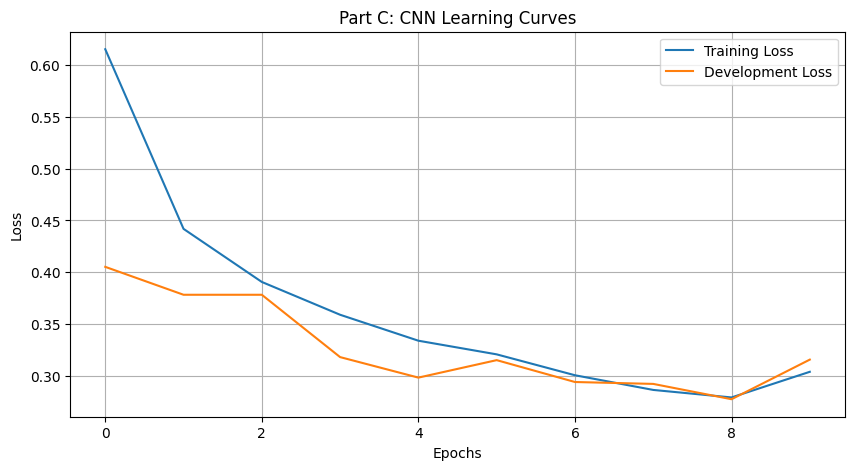


 Running Final Evaluation on Test Set...

FashionMNIST Final Test Results
              precision    recall  f1-score   support

 T-shirt/top     0.8277    0.8550    0.8411      1000
     Trouser     0.9939    0.9760    0.9849      1000
    Pullover     0.7338    0.8850    0.8024      1000
       Dress     0.8772    0.9360    0.9057      1000
        Coat     0.8405    0.6800    0.7518      1000
      Sandal     0.9885    0.9440    0.9657      1000
       Shirt     0.7350    0.6600    0.6955      1000
     Sneaker     0.9332    0.9640    0.9484      1000
         Bag     0.9790    0.9780    0.9785      1000
  Ankle boot     0.9450    0.9620    0.9534      1000

    accuracy                         0.8840     10000
   macro avg     0.8854    0.8840    0.8827     10000
weighted avg     0.8854    0.8840    0.8827     10000



In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

#  SETUP & HYPERPARAMETERS
# Hardware Check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Hardware Check: Training on {device}")

BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001

# DATA AUGMENTATION & LOADING
# FashionMNIST is grayscale. We normalize using mean=0.5, std=0.5
# Requirement: Data Augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),    # Augmentation
    transforms.RandomRotation(10),        # Augmentation
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# No augmentation for validation/test
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print(" Downloading FashionMNIST Dataset...")
full_train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=train_transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=test_transform
)

# Create Development Set (20% of training data)
train_size = int(0.8 * len(full_train_dataset))
dev_size = len(full_train_dataset) - train_size
train_dataset, dev_dataset = random_split(full_train_dataset, [train_size, dev_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# MODEL DEFINITION (Fine-Tuning ResNet)
# Requirement: CNN Encoder + MLP
class FashionResNet(nn.Module):
    def __init__(self):
        super(FashionResNet, self).__init__()
        # Load pre-trained ResNet18
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # MODIFICATION 1: Input Channels
        # ResNet expects 3 channels (RGB), FashionMNIST is 1 (Grayscale).
        # We replace the first conv layer to accept 1 channel.
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # MODIFICATION 2: MLP Head
        # Replace the final fully connected layer with a custom MLP
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(in_features, 256),   # Hidden Layer
            nn.ReLU(),
            nn.Dropout(0.3),               # Regularization
            nn.Linear(256, 10)             # Output Layer (10 Classes)
        )

    def forward(self, x):
        return self.resnet(x)

model = FashionResNet().to(device)

# Requirement: Adam Optimizer [cite: 42]
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

#  TRAINING LOOP
print("\n Starting Training (CNN)...")
train_losses, dev_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        # Move batch to GPU
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation Phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in dev_loader:
            images, labels = images.to(device), labels.to(device)
            loss = criterion(model(images), labels)
            val_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    avg_dev_loss = val_loss / len(dev_loader)

    train_losses.append(avg_train_loss)
    dev_losses.append(avg_dev_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Dev Loss: {avg_dev_loss:.4f}")

# RESULTS & VISUALIZATION
# Requirement: Loss Curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(dev_losses, label='Development Loss')
plt.title('Part C: CNN Learning Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Final Evaluation on Test Data
print("\n Running Final Evaluation on Test Set...")
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Map class indices to names
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("\nFashionMNIST Final Test Results")
# Requirement: Precision, Recall, F1 Table
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))